In [2]:
import numpy as np
import pandas as pd 
import matplotlib as mpl

df = pd.read_csv("../data/vehiculos_procesados_sin_electricos.csv")

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,10) # Figuras de plt a 10x10 pulgadas

In [3]:
df.head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,c02
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500


In [7]:
def valores_unicos_col(ds):
    for columna in ds:
        print("{} | {} | {}".format(
            df[columna].name, len(df[columna].unique()), df[columna].dtype )
        )
valores_unicos_col(df)

fabricante | 129 | object
modelo | 3734 | object
year | 35 | int64
desplazamiento | 66 | float64
cilindros | 10 | float64
transmision | 38 | object
traccion | 8 | object
clase | 34 | object
combustible | 13 | object
consumo | 49 | int64
c02 | 596 | float64


In [8]:
df.clase.unique()

array(['Special Purpose Vehicle 2WD', 'Midsize Cars', 'Subcompact Cars',
       'Compact Cars', 'Sport Utility Vehicle - 4WD',
       'Small Sport Utility Vehicle 2WD',
       'Small Sport Utility Vehicle 4WD', 'Two Seaters',
       'Sport Utility Vehicle - 2WD', 'Special Purpose Vehicles',
       'Special Purpose Vehicle 4WD', 'Small Station Wagons',
       'Minicompact Cars', 'Midsize-Large Station Wagons',
       'Midsize Station Wagons', 'Large Cars',
       'Standard Sport Utility Vehicle 4WD',
       'Standard Sport Utility Vehicle 2WD', 'Minivan - 4WD',
       'Minivan - 2WD', 'Vans', 'Vans, Cargo Type',
       'Vans, Passenger Type', 'Standard Pickup Trucks 2WD',
       'Standard Pickup Trucks', 'Standard Pickup Trucks/2wd',
       'Small Pickup Trucks 2WD', 'Standard Pickup Trucks 4WD',
       'Small Pickup Trucks 4WD', 'Small Pickup Trucks', 'Vans Passenger',
       'Special Purpose Vehicle', 'Special Purpose Vehicles/2wd',
       'Special Purpose Vehicles/4wd'], dtype=object

In [16]:
pequeno = ["Compact Cars", "Subcompact Cars", "Two Seaters", "Minicompact Cars"]
mediano = ["Midsize Cars"]
grande = ["Large Cars"]

df.loc[df['clase'].isin(pequeno), 'clase_tipo'] = 'Coches pequeños'

df.loc[df['clase'].isin(mediano), 'clase_tipo'] = 'Coches medianos'

df.loc[df['clase'].isin(grande), 'clase_tipo'] = 'Coches grandes'

df.loc[df['clase'].str.contains('Truck'), 'clase_tipo'] = 'Camiones'

df.loc[df['clase'].str.contains('Special Purpose'), 'clase_tipo'] = 'Vehiculos Especiales'

df.loc[df['clase'].str.contains('Sport Utility'), 'clase_tipo'] = 'Deportivo'

df.loc[df['clase'].str.contains('Station'), 'clase_tipo'] = 'Coche Familiar'

df.loc[df['clase'].str.lower().str.contains('Van'), 'clase_tipo'] = 'Vans'

In [17]:
df.clase_tipo = df.clase_tipo.astype("category")

In [25]:
df.clase_tipo.dtype

CategoricalDtype(categories=['Camiones', 'Coche Familiar', 'Coches grandes',
                  'Coches medianos', 'Coches pequeños', 'Deportivo',
                  'Vehiculos Especiales'],
                 ordered=False)

<AxesSubplot:>

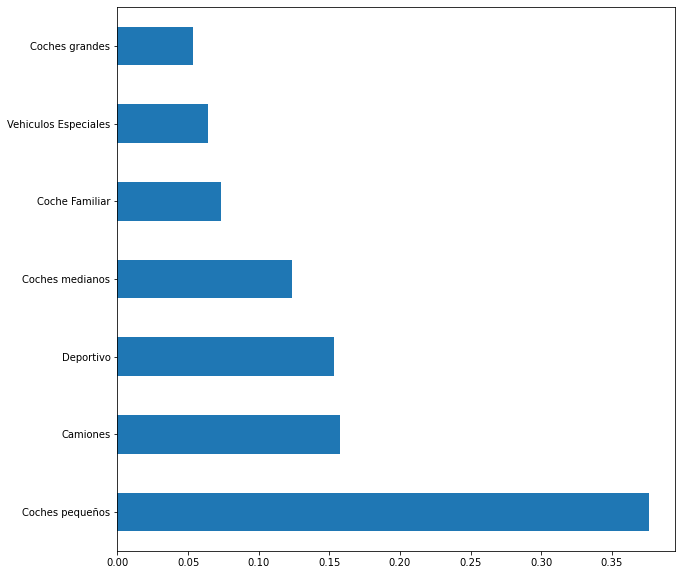

In [24]:
df.clase_tipo.value_counts(normalize=True).plot.barh()

In [26]:
df.traccion.unique()

array(['2-Wheel Drive', 'Rear-Wheel Drive', 'Front-Wheel Drive',
       '4-Wheel or All-Wheel Drive', 'All-Wheel Drive', nan,
       '4-Wheel Drive', 'Part-time 4-Wheel Drive'], dtype=object)

In [29]:
df['traccion_tipo'] = 'dos'
df.loc[df.traccion.isin(['4-Wheel or All-Wheel Drive', 'All-Wheel Drive',
       '4-Wheel Drive', 'Part-time 4-Wheel Drive']), 'traccion_tipo'] = 'cuatro'

In [30]:
df.traccion_tipo = df.traccion_tipo.astype("category")

In [31]:
df.traccion_tipo.value_counts()

dos       26868
cuatro     9923
Name: traccion_tipo, dtype: int64

# Transmision

In [33]:
df.transmision.unique()

array(['Automatic 3-spd', 'Automatic 4-spd', 'Manual 5-spd',
       'Automatic (S5)', 'Manual 6-spd', 'Automatic 5-spd',
       'Automatic (AM8)', 'Automatic (AM-S8)', 'Automatic (AV-S7)',
       'Automatic (S6)', 'Automatic (S9)', 'Automatic (AM-S7)',
       'Automatic (S4)', 'Automatic (AM-S9)', 'Automatic (S7)',
       'Automatic (AM7)', 'Automatic (AM6)', 'Automatic 6-spd',
       'Automatic 8-spd', 'Manual 4-spd', 'Automatic (S8)',
       'Manual 7-spd', 'Automatic (AM-S6)', 'Auto(AM-S6)',
       'Automatic (variable gear ratios)', 'Automatic (AV-S8)',
       'Automatic (A1)', 'Automatic (AV-S6)', 'Manual 3-spd',
       'Automatic (S10)', 'Automatic 9-spd', 'Manual 4-spd Doubled', nan,
       'Automatic (L4)', 'Automatic (L3)', 'Automatic (AV-S10)',
       'Automatic 7-spd', 'Automatic (AM5)'], dtype=object)

In [42]:
df['transmision_tipo'] = 'Automatica'

#df.loc[df['transmision'].str.startswith('M'),'transmision_tipo'] = 'Manual'

df['transmision_tipo'][(df.transmision.notnull()) & (df['transmision'].str.startswith('M'))] = 'Manual'

C:\Users\LENOVO\miniconda3\envs\udemy-python\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


In [44]:
df.transmision_tipo = df.transmision_tipo.astype("category")

In [45]:
df.transmision_tipo.value_counts()

Automatica    24937
Manual        11854
Name: transmision_tipo, dtype: int64

In [46]:
df.combustible.value_counts()

Regular                        24078
Premium                        10206
Gasoline or E85                 1215
Diesel                           933
Premium or E85                   124
Midgrade                          77
CNG                               60
Premium and Electricity           30
Gasoline or natural gas           20
Regular Gas and Electricity       20
Premium Gas or Electricity        18
Gasoline or propane                8
Regular Gas or Electricity         2
Name: combustible, dtype: int64

In [47]:
df['combustible_tipo'] = 'Otro tipo de combustible'

df.loc[df['combustible'] == 'Regular', 'combustible_tipo'] = "Normal"
df.loc[df['combustible'] == 'Premium', 'combustible_tipo'] = "Premium"
df.loc[df['combustible'].str.contains('Eletricity'), 'combustible_tipo'] = "Hibrido"

In [48]:
df.combustible_tipo = df.combustible_tipo.astype("category")

In [49]:
df.combustible_tipo.value_counts()

Normal                      24078
Premium                     10206
Otro tipo de combustible     2507
Name: combustible_tipo, dtype: int64

In [51]:
df.head(10)

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,c02,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehiculos Especiales,dos,Automatica,Normal
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehiculos Especiales,dos,Automatica,Normal
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehiculos Especiales,dos,Automatica,Normal
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehiculos Especiales,dos,Automatica,Normal
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches medianos,dos,Automatica,Premium
5,Acura,2.2CL/3.0CL,1997,2.2,4.0,Automatic 4-spd,Front-Wheel Drive,Subcompact Cars,Regular,22,403.954545,Coches pequeños,dos,Automatica,Normal
6,Acura,2.2CL/3.0CL,1997,2.2,4.0,Manual 5-spd,Front-Wheel Drive,Subcompact Cars,Regular,24,370.291667,Coches pequeños,dos,Manual,Normal
7,Acura,2.2CL/3.0CL,1997,3.0,6.0,Automatic 4-spd,Front-Wheel Drive,Subcompact Cars,Regular,20,444.350000,Coches pequeños,dos,Automatica,Normal
8,Acura,2.3CL/3.0CL,1998,2.3,4.0,Automatic 4-spd,Front-Wheel Drive,Subcompact Cars,Regular,22,403.954545,Coches pequeños,dos,Automatica,Normal
9,Acura,2.3CL/3.0CL,1998,2.3,4.0,Manual 5-spd,Front-Wheel Drive,Subcompact Cars,Regular,24,370.291667,Coches pequeños,dos,Manual,Normal


# Variables Continuas

In [56]:
tipo_tamano_motor = ['muy pequeno', 'pequeno', 'mediano', 'grande', 'muy grande']

df['tamano_motor_tipo'] = pd.qcut(df['desplazamiento'],5,tipo_tamano_motor)

tipo_consumo = ['muy bajo', 'bajo', 'mediano', 'alto', 'muy alto']

df['tipo_consumo'] = pd.qcut(df['consumo'],5,tipo_consumo)

tipo_c02 = ['muy bajo', 'bajo', 'mediano', 'alto', 'muy alto']

df['tipo_c02'] = pd.qcut(df['c02'],5,tipo_c02)

In [57]:
df.head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,c02,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,tipo_consumo,tipo_c02
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehiculos Especiales,dos,Automatica,Normal,pequeno,bajo,alto
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehiculos Especiales,dos,Automatica,Normal,grande,muy bajo,muy alto
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehiculos Especiales,dos,Automatica,Normal,pequeno,muy bajo,alto
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehiculos Especiales,dos,Automatica,Normal,grande,muy bajo,muy alto
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches medianos,dos,Automatica,Premium,grande,muy bajo,alto


<AxesSubplot:xlabel='consumo', ylabel='c02'>

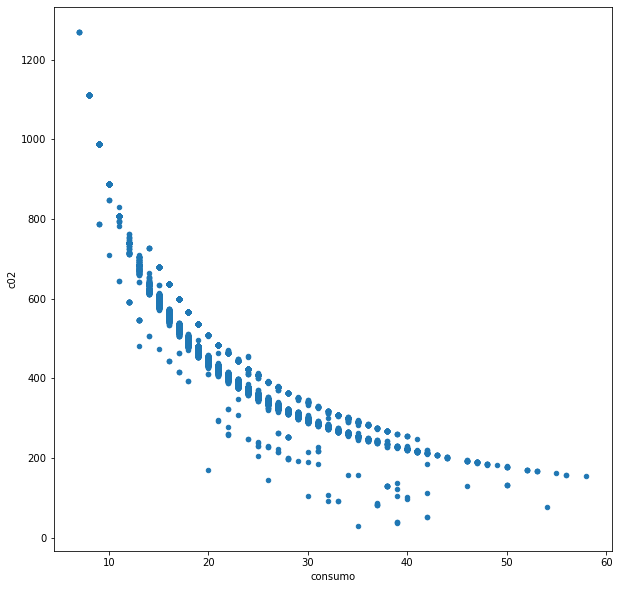

In [58]:
df.plot.scatter(x="consumo", y="c02")

In [59]:
litros_por_galon = 3.78541
df['consumo_litro_milla'] = litros_por_galon / df.consumo

<AxesSubplot:xlabel='consumo_litro_milla', ylabel='c02'>

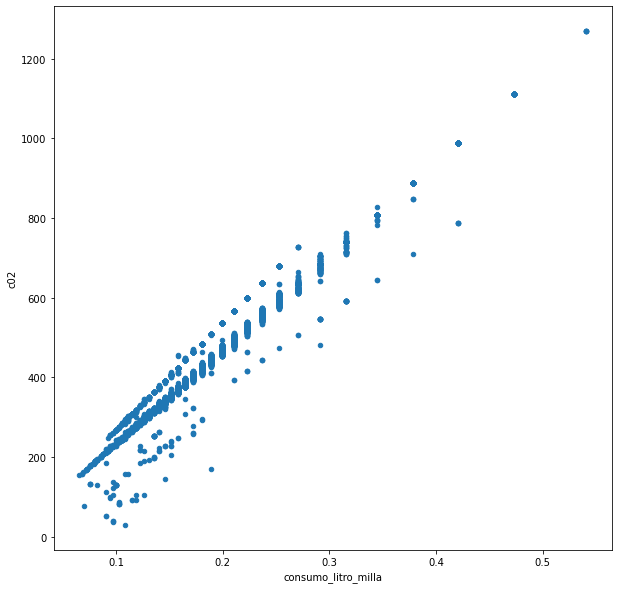

In [60]:
df.plot.scatter(x="consumo_litro_milla", y="c02")

In [63]:
tipo_consumo = ['muy bajo', 'bajo', 'mediano', 'alto', 'muy alto']

df['tipo_consumo'] = pd.qcut(df['consumo_litro_milla'],5,labels=tipo_consumo)

In [64]:
df.tipo_consumo.head()

0        alto
1    muy alto
2        alto
3    muy alto
4        alto
Name: tipo_consumo, dtype: category
Categories (5, object): ['muy bajo' < 'bajo' < 'mediano' < 'alto' < 'muy alto']

In [65]:
 df.head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,c02,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,tipo_consumo,tipo_c02,consumo_litro_milla
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehiculos Especiales,dos,Automatica,Normal,pequeno,alto,alto,0.222671
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehiculos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehiculos Especiales,dos,Automatica,Normal,pequeno,alto,alto,0.236588
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehiculos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


In [66]:
df.dtypes

fabricante               object
modelo                   object
year                      int64
desplazamiento          float64
cilindros               float64
transmision              object
traccion                 object
clase                    object
combustible              object
consumo                   int64
c02                     float64
clase_tipo             category
traccion_tipo          category
transmision_tipo       category
combustible_tipo       category
tamano_motor_tipo      category
tipo_consumo           category
tipo_c02               category
consumo_litro_milla     float64
dtype: object

### Conclusiones

* Se encontro que habia una relacion inversamente proporcional entre c02 y consumo, debido a que el dataset original tenia registros de consumo en galones en lugar de litros, ajustando el calculo de consumo a galones por milla, se pudo obtener una relacion directamente proporcional entre consumo y c02

Para guardar dataframes no finales si no en proceso, mejor guardar en pickle en lugar de csv por que se corre el riesgo de perderse informacion que pandas genero.

In [67]:
df.to_pickle('../data/vehiculos_2_procesado_categorizado.pkl')